In [2]:
# import scqubits
# import numpy as np
# from scipy.optimize import minimize


import sys
original_sys_path = sys.path.copy()
sys.path.append('../')
from utils import *


max overlap^2 0.09270261911848941 below threshold for dressed state 1380 with eval 216.65359068368394

qubit 12 transition and differential stark at different oscillator level
qbt freq at osc 0:	0.009264115316100163
qbt freq at osc 1:	0.00938, 	diff to at osc ground 0.00011, 1.2327% diff
qbt freq at osc 2:	0.00954, 	diff to at osc ground 0.00028, 2.9701% diff
qbt freq at osc 3:	0.00975, 	diff to at osc ground 0.00049, 5.2490% diff
qbt freq at osc 4:	0.01001, 	diff to at osc ground 0.00075, 8.1045% diff
qbt freq at osc 5:	0.01034, 	diff to at osc ground 0.00107, 11.5702% diff
qbt freq at osc 6:	0.01072, 	diff to at osc ground 0.00145, 15.6787% diff
qbt freq at osc 7:	0.01116, 	diff to at osc ground 0.00190, 20.4615% diff
qbt freq at osc 8:	0.01167, 	diff to at osc ground 0.00240, 25.9492% diff
qbt freq at osc 9:	0.01224, 	diff to at osc ground 0.00298, 32.1723% diff
qbt freq at osc 10:	0.01289, 	diff to at osc ground 0.00363, 39.1605% diff
qbt freq at osc 11:	0.01361, 	diff to at osc gr

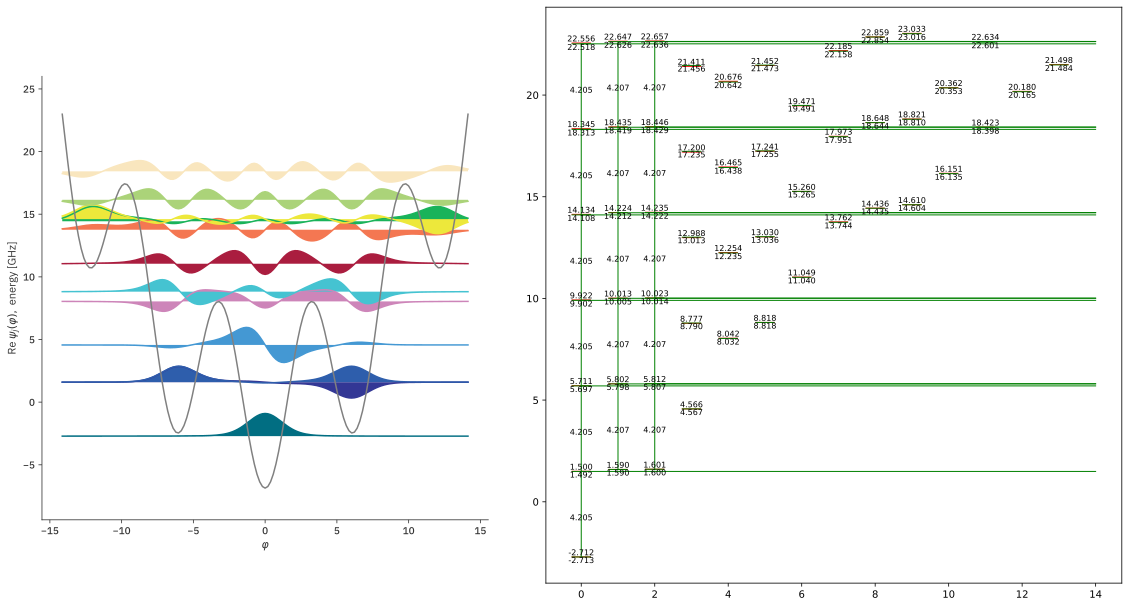

In [8]:
EJ = 6.86
EC = 1.45
EL = 0.23
Er = 4.21132

qubit_level = 30


# def get_shift_accurate(ele,omega_i, omega_j, omega_r):
#     return abs(ele)**2 / (omega_j-omega_i-omega_r) - abs(ele)**2 / (omega_i-omega_j-omega_r)


# qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)
# evals = qbt.eigenvals(qubit_level)
# elements = qbt.matrixelement_table('n_operator',evals_count = qubit_level)

# def shift_diff(x):
#     Er = x[0]

#     shifts_from_one = [get_shift_accurate(elements[1,ql2],evals[ql2],evals[1],Er) for ql2 in range(qubit_level)] 
#     shift_from_one = sum(shifts_from_one)
#     shifts_from_two = [get_shift_accurate(elements[2,ql2],evals[ql2],evals[2],Er) for ql2 in range(qubit_level)] 
#     shift_from_two = sum(shifts_from_two)
#     return abs(shift_from_one-shift_from_two)

# initial_guess = [4.21]

# # Call the optimizer
# result = minimize(shift_diff, initial_guess, method='Nelder-Mead')

# print("Result:", result)
# print("Optimal solution:", result.x)
# print("Objective value:", result.fun)



max_ol = 50
max_ql = 30
g = 0.20
system = fluxonium_oscillator_system(
    EJ = EJ,
    EC = EC,
    EL = EL,
    # Er = result.x[0],
    Er = Er,
    g_strength = g,
    qubit_level = max_ql,
    osc_level = max_ol,
    # kappa = 0.004,
    products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
    computaional_states= '1,2'
    )


energies=  system.hilbertspace.eigenvals(max_ql * max_ol)
def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]
def print_stats():
    print(f"\nqubit 12 transition and differential stark at different oscillator level")
    print(f"qbt freq at osc {0}:\t{(dressed_ener(2,0)-dressed_ener(1,0))}")
    ground_freq = dressed_ener(2,0)-dressed_ener(1,0)
    for i in range(1,max_ol-1):
        freq = dressed_ener(2,i)-dressed_ener(1,i)
        print(f"qbt freq at osc {i}:\t{freq:.5f}, \tdiff to at osc ground {freq - ground_freq:.5f}, {abs(freq - ground_freq)/ground_freq*100:.4f}% diff")

    print(f"\noscillator freq at qubit level:\t0 \t 1 \t 2 \t 3:")
    print(f"oscillator transition 0-1: \t{dressed_ener(0,1)-dressed_ener(0,0):.5f}\t{dressed_ener(1,1)-dressed_ener(1,0):.5f}\t{dressed_ener(2,1)-dressed_ener(2,0):.5f}\t{dressed_ener(3,1)-dressed_ener(3,0):.5f}")
    for i in range(1,max_ol-1):
        print(f"oscillator transition {i}-{i+1}: \t{dressed_ener(0,i+1)-dressed_ener(0,i):.5f}\t{dressed_ener(1,i+1)-dressed_ener(1,i):.5f}\t{dressed_ener(2,i+1)-dressed_ener(2,i):.5f}\t{dressed_ener(3,i+1)-dressed_ener(3,i):.5f}  oscillator frequency coupled to qubit 0th state compared to 00-01 (non-linearity): {(dressed_ener(0,i+1)-dressed_ener(0,i))  -(dressed_ener(0,1)-dressed_ener(0,0))}")

    print(f"")
    print(f"10-11: {(dressed_ener(1,1)-dressed_ener(1,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(1,1)-dressed_ener(1,0)))}")
    print(f"20-21: {(dressed_ener(2,1)-dressed_ener(2,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(2,1)-dressed_ener(2,0)))}")
print_stats()
plot_specturum(system.qbt, system.osc, system.hilbertspace,num_levels = 50)